In [1]:
from data_handling import *
base_fp = '/trace/group/rounce/cvwilson/'

2018-05-01
2018-05-13
2018-05-25


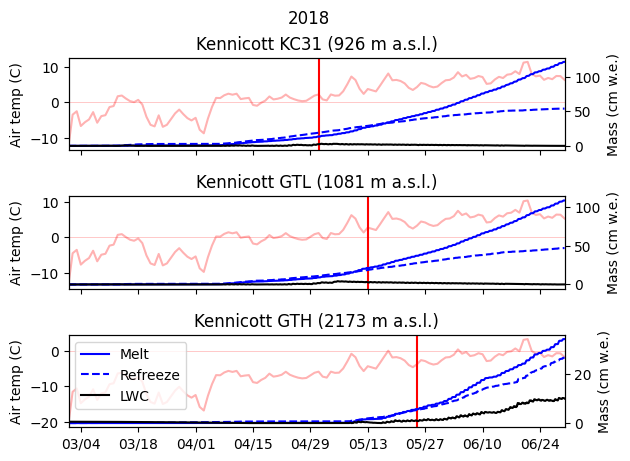

In [67]:
glacier = 'kennicott'
sites = ['KC31','GTL','GTH']
site_elev = {'KC31':926, 'GTL':1081, 'GTH':2173}

results = []

# print('PEBSI modeled cumulative melt and LWC at SAR-derived melt onset dates')
# print('   (averaged across descending scenes, 2018-2024)')

fig, axes = plt.subplots(3, gridspec_kw = {'hspace':0.5}, sharex='col') # , figsize=(15, 6))
for ax, site in zip(axes, sites):
    ds = xr.open_dataset(base_fp + f'Output/ddf/{glacier}{site}_2026_05_05_test_0.nc')
    sar = SnowMelt(glacier, site, 'Descending')

    melt_df = sar.sar_melt['med']
    cum_melt_list = []
    cum_rfz_list = []
    lwc_list = []
    ax2 = ax.twinx()
    
    for year in np.unique(melt_df.index.year)[1:2]:
        
        # Clip dataset to this year
        df_year = melt_df.loc[melt_df.index.year == year]
            
        # Get onset date from SAR
        sar_melt_onset = df_year.loc[df_year].index[0].strftime('%Y-%m-%d')
        print(sar_melt_onset)

        # Clip dataset up to this date and get cumulative melt
        period_start = pd.to_datetime(f'{year}-03-01')
        period_end = pd.to_datetime(f'{year}-06-30')
        ds_clipped = ds.sel(time=slice(period_start, period_end))
        summed_melt = ds_clipped.melt.sum().values
        summed_rfz = ds_clipped.refreeze.sum().values
        
        # Get LWC in m w.e.
        morning_lwc = (ds
                       .sel(time=pd.to_datetime(sar_melt_onset).replace(hour=8))
                       .layerwater.sum(dim='layer').values
        ) / 1000
        
        cum_melt_list.append(summed_melt)
        cum_rfz_list.append(summed_rfz)
        lwc_list.append(morning_lwc)

        time = ds_clipped.time.values
        daily = ds_clipped.airtemp.resample(time='d').mean()
        ax.plot(daily.time, daily.values, c='r', alpha=0.3,label='Air temperature')
        ax.axhline(0, c='r', alpha=0.3, linewidth=0.5)
        ax2.plot(time, ds_clipped.melt.cumsum()*100, c='blue',label='Melt')
        ax2.plot(time, ds_clipped.refreeze.cumsum()*100, c='blue',linestyle='--',label='Refreeze')
        ax2.plot(time, ds_clipped.layerwater.sum(dim='layer') / 10, c='k',label='LWC')
        ax.axvline(pd.to_datetime(sar_melt_onset), c='r',label='SAR melt onset')
        # ax2.axhline(0, c='k', alpha=0.3, linewidth=0.5)
        ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%m/%d'))
        ax.set_xlim(period_start, period_end)
        ax.set_xticks(pd.date_range(period_start, period_end, freq='2W'))
        elev = site_elev[site]
        ax.set_title(f'{glacier.capitalize()} {site} ({elev} m a.s.l.)')
        ax.set_ylabel('Air temp (C)')
        ax2.set_ylabel('Mass (cm w.e.)')

# axes[0].legend(bbox_to_anchor=(0.18, 0.72), loc='center')
ax2.legend()
fig.suptitle(str(year))
plt.show()

#     # Calculate means and standard deviations (converted to cm w.e.)
#     results.append({
#         'Site': site,
#         'Avg Cum Melt (cm)': np.nanmean(cum_melt_list) * 100,
#         'Melt StdDev': np.nanstd(cum_melt_list) * 100,
#         'Avg Cum Rfz (cm)': np.nanmean(cum_rfz_list) * 100,
#         'Rfz StdDev': np.nanstd(cum_rfz_list) * 100,
#         'Avg LWC (cm)': np.nanmean(lwc_list) * 100,
#         'LWC StdDev': np.nanstd(lwc_list) * 100
#     })

# # Create DataFrame for pretty printing
# summary_df = pd.DataFrame(results)

# # Option 1: Print using Pandas (simple)
# print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Option 2: Use tabulate if you have it installed for a "Prettier" look
# from tabulate import tabulate
# print(tabulate(summary_df, headers='keys', tablefmt='psql', floatfmt=".2f"))


Text(0, 0.5, 'Count')

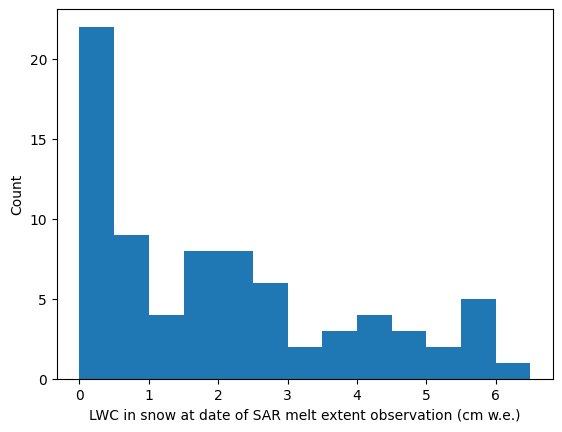

In [20]:
all_elevs = np.array(list(range(500, 2000, 100)) + list(range(2000, 4400, 500)))

by_elev = {}
for elev in all_elevs:
    ds = xr.open_dataset(f'/trace/group/rounce/cvwilson/Output/ddf/kennicottK{elev}_2026_05_06_sar_test_0.nc')
    by_elev[elev] = ds

s = SnowMelt('kennicott', 'GTH', 'Descending')
df = s.df_melt

df = df.loc[df.index.year > 2017]
df = df[df.ne(df.shift()).any(axis=1)]
df = df.loc[df.index.month < 8]

nearest_elev_lwc = []
for date in df.index:
    melt_elev = df.loc[date, 'melt_extent_elev_m']
    if np.min(np.abs(all_elevs - melt_elev)) < 100:
        nearest = all_elevs[np.argmin(np.abs(all_elevs - melt_elev))]
        ds = by_elev[nearest]
        lwc = (ds.sel(time=pd.to_datetime(date).replace(hour=8))
                    .layerwater.sum(dim='layer').values
        ) / 10 # from kg m-2 to cm w.e.
        
        nearest_elev_lwc.append(lwc)

bins = np.arange(0, 7, 0.5)
plt.hist(nearest_elev_lwc, bins=bins)
plt.xlabel('LWC in snow at date of SAR melt extent observation (cm w.e.)')
plt.ylabel('Count')

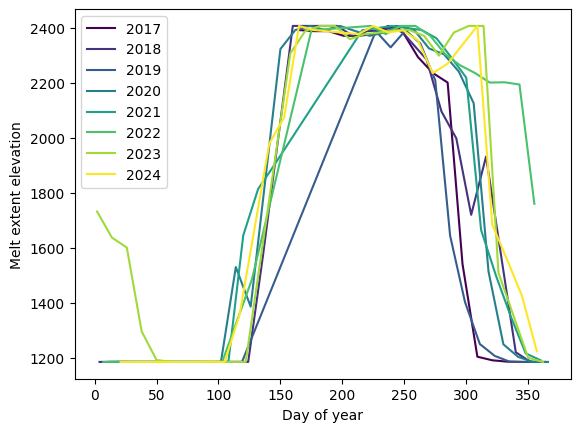

In [55]:
df = pd.read_csv('/trace/group/rounce/cvwilson/rs/sar/01.05299/01.05299_melt_extent_elev_percentile_160_379.csv')
df.index = pd.to_datetime(df['Unnamed: 0'])
df['doy'] = df.index.day_of_year 

cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=2017, vmax=2024)
for year in np.unique(df.index.year):
    a = df.loc[df.index.year == year]
    plt.plot(a.doy, a.melt_extent_elev_m, c=cmap(norm(year)),label=str(year))
plt.ylabel('Melt extent elevation')
plt.legend()
plt.xlabel('Day of year')
plt.show()